<a href="https://colab.research.google.com/github/i-indhugit/Pragyan_khel_Codex/blob/main/Minor_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [5]:
df = pd.read_csv("spotify_songs.csv")

df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [7]:
print(df.columns)


Index(['track_id', 'track_name', 'track_artist', 'track_popularity',
       'track_album_id', 'track_album_name', 'track_album_release_date',
       'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'duration_ms'],
      dtype='object')


In [11]:
df = df.drop(
    columns=[
        "track_id",
        "track_artist",
        "track_album_name",
        "playlist_name"
    ],
    errors="ignore"
)

df = df.dropna()

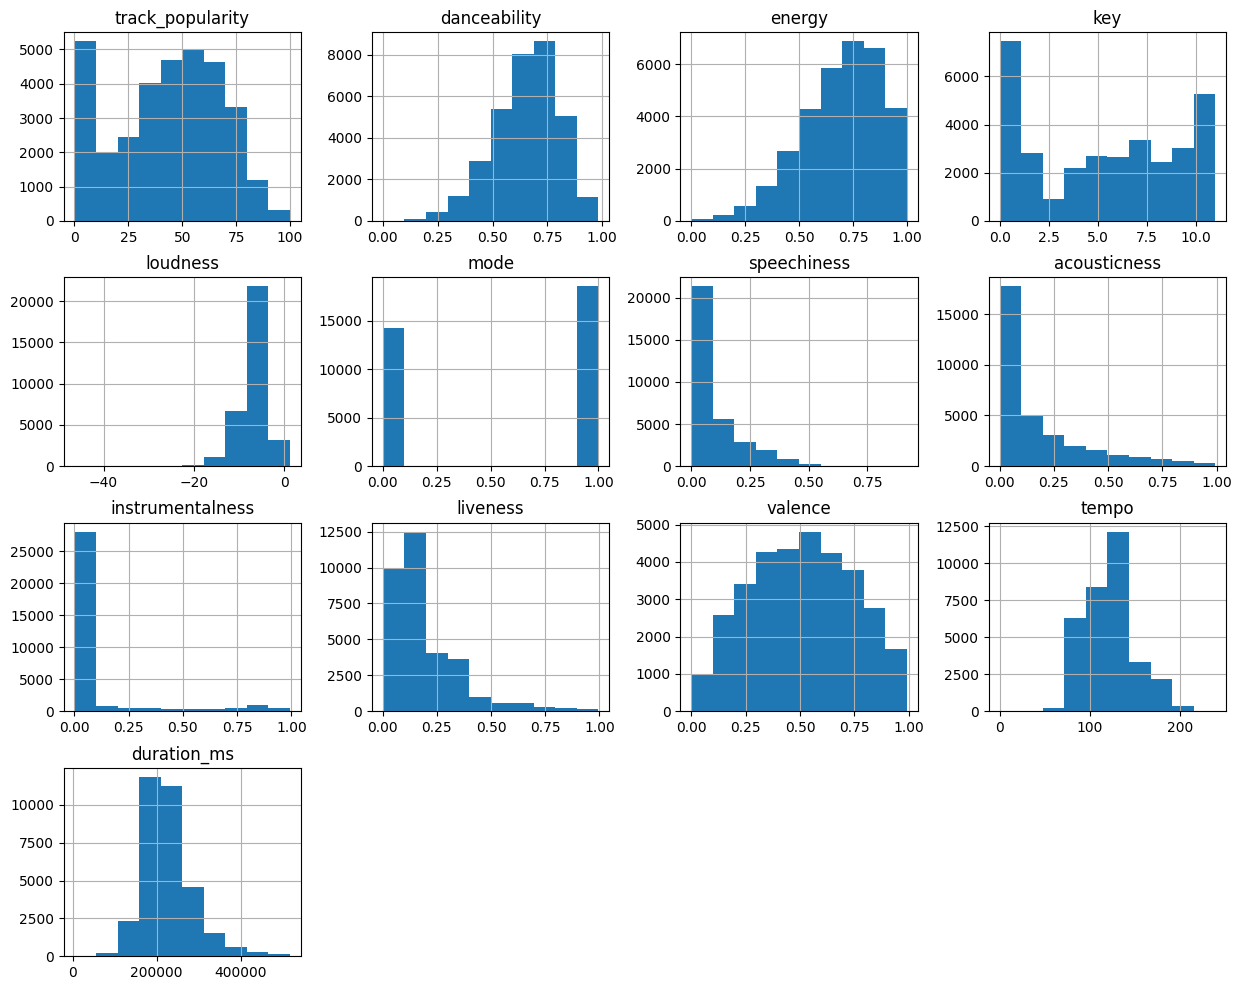

In [13]:
df.hist(figsize=(15,12))
plt.show()

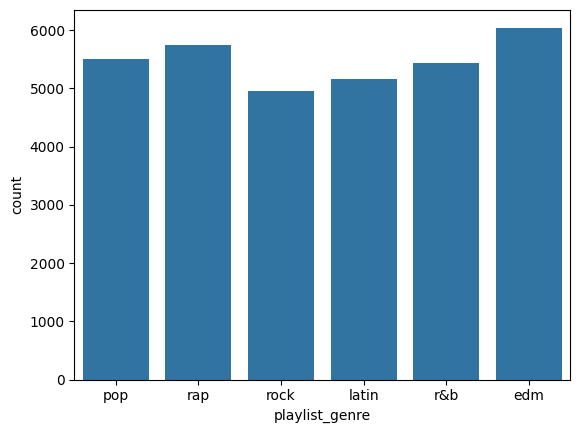

In [15]:
sns.countplot(x="playlist_genre", data=df)

plt.show()

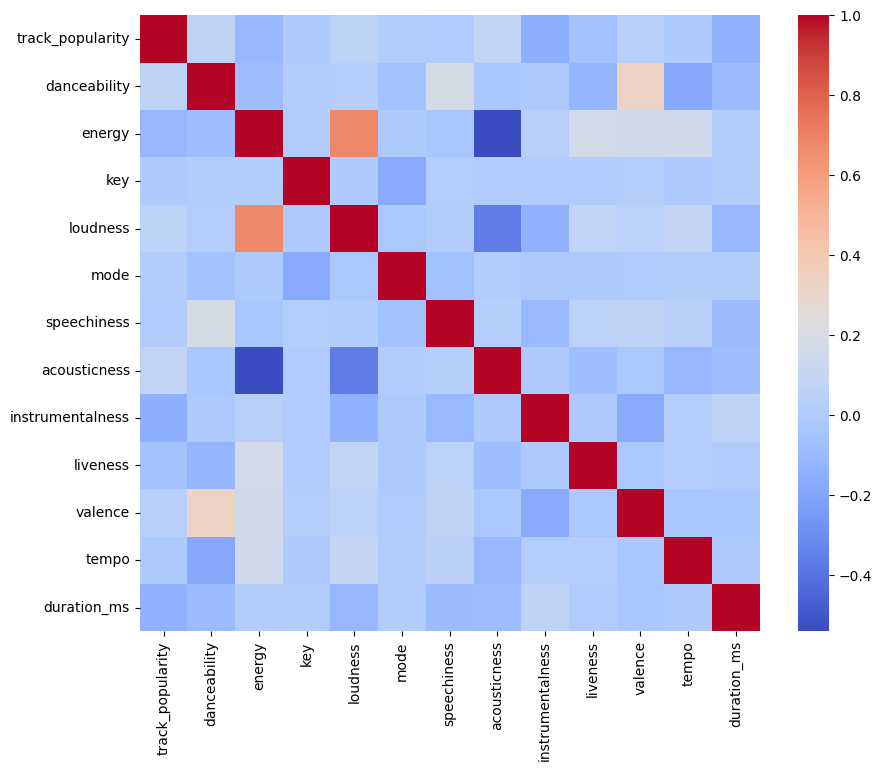

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.show()

In [20]:
features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

X = df[features]

y = df["playlist_genre"]
print(X.shape)
print(y.shape)

(32828, 9)
(32828,)


In [21]:
le = LabelEncoder()
y = le.fit_transform(y)
y

array([2, 2, 2, ..., 0, 0, 0])

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8)#train and test

In [27]:
print(X_train)
print(y_train)
print(X_test)
print(y_test)

       danceability  energy  loudness  speechiness  acousticness  \
3038          0.655   0.666    -5.309       0.0612       0.13400   
8801          0.502   0.736    -8.480       0.3850       0.00617   
23008         0.689   0.463    -8.121       0.0365       0.06600   
4410          0.702   0.603    -6.833       0.0598       0.16800   
20197         0.583   0.944    -3.301       0.2760       0.00557   
...             ...     ...       ...          ...           ...   
25362         0.894   0.307    -8.941       0.1150       0.17300   
4500          0.312   0.789    -6.290       0.0615       0.02510   
9493          0.785   0.752    -5.216       0.2600       0.03900   
29818         0.798   0.837    -2.531       0.0582       0.00737   
10215         0.727   0.431   -12.007       0.3950       0.01110   

       instrumentalness  liveness  valence    tempo  
3038           0.000021    0.0683    0.272  102.977  
8801           0.000000    0.1580    0.393  178.220  
23008          0.0001

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_scaled = scaler.fit_transform(X)
print(X_scaled)

[[ 0.6420147   1.20166767  1.36704001 ... -0.80924586  0.03192873
   0.04283347]
 [ 0.4903842   0.6433885   0.58573644 ...  1.08109448  0.78252502
  -0.77729134]
 [ 0.13887713  1.28458042  1.10002492 ... -0.5195708   0.43939529
   0.11613324]
 ...
 [-0.86739801  0.6765536   0.60915882 ... -0.26035375 -0.31977924
   0.26410808]
 [-0.19884535  1.04689721  1.1237819  ...  0.99036851 -0.86878681
   0.26481432]
 [-0.35736815  1.02478714  0.71890938 ...  3.57605858 -1.8063888
   0.26392223]]


In [31]:
model = KMeans(n_clusters=6)

model.fit(X_train)

KMeans(n_clusters=6)

In [35]:
y_pred = model.predict(X_test)

print("Predicted:", y_pred[:5])
print("Actual:", y_test[:5])

Predicted: [4 5 4 0 3]
Actual: [0 2 0 4 4]


In [36]:
model2 = KMeans(n_clusters=6)

df["Cluster"] = model2.fit_predict(X_scaled)

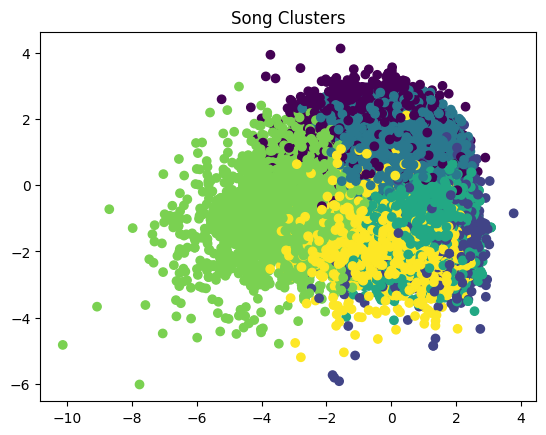

In [37]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(X_scaled)

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Song Clusters")

plt.show()

In [38]:
def recommend_song(song_name):

    song = df[df["track_name"] == song_name]

    if song.empty:
        print("Song not found")
        return

    cluster = song["Cluster"].values[0]

    rec = df[df["Cluster"] == cluster]

    return rec[
        ["track_name","playlist_genre"]
    ].head(10)

In [53]:
recommend_song("Daydreams")

,track_name,playlist_genre
3,Call You Mine - Keanu Silva Remix,pop
6,Never Really Over - R3HAB Remix,pop
7,Post Malone (feat. RANI) - GATTÜSO Remix,pop
11,Hate Me - R3HAB Remix,pop
13,SOS - Laidback Luke Tribute Remix / Radio Edit,pop
14,Summer Days (feat. Macklemore & Patrick Stump ...,pop
19,Let It Be Me - Sondr Remix,pop
20,Heaven - David Guetta & MORTEN Remix,pop
22,Don't Leave Me Alone (feat. Anne-Marie) - EDX'...,pop
23,Slow Dance (feat. Ava Max) - Sam Feldt Remix,pop
